# Raidium Challenge 2025 — Baseline Model

**Environment:** Google Colab + T4 GPU  
**Before running:** `Runtime → Change runtime type → T4 GPU → Save`

## Table of Contents
1. [Mount Google Drive & Extract Data](#setup)
2. [Imports & Config](#imports)
3. [Load Data](#data)
4. [Model Choice](#model-choice)
5. [Feature Selection & Preprocessing](#features)
6. [Implementation](#implementation)
7. [Evaluation](#evaluation)
8. [Submission](#submission)

---
## 1. Mount Google Drive & Extract Data <a id='setup'></a>

Upload the following files to a folder in your Google Drive (e.g. `MyDrive/raidium/`):
- `x_train.zip`
- `x_test.zip`
- `y_train.csv`
- `annotated_labels.json`

Then run this cell. It mounts Drive, copies everything to Colab's fast local disk, and extracts the zips. You only need to do this once per session.

In [1]:
from google.colab import drive
import shutil, zipfile
from pathlib import Path

# ── Mount Drive ───────────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Set this to wherever you put your files in Drive ─────────────────────────
DRIVE_DIR = Path("/content/drive/MyDrive/raidium")

# ── Local working directory on Colab's fast disk ─────────────────────────────
LOCAL_DIR = Path("/content/raidium")
LOCAL_DIR.mkdir(exist_ok=True)

# ── Copy flat files ───────────────────────────────────────────────────────────
for filename in ["y_train.csv", "annotated_labels.json"]:
    src = DRIVE_DIR / filename
    dst = LOCAL_DIR / filename
    if not dst.exists():
        print(f"Copying {filename} …")
        shutil.copy(str(src), str(dst))
    else:
        print(f"{filename} already present, skipping.")

# ── Extract zips (skip if already extracted) ─────────────────────────────────
for zip_name, extract_check in [
    ("x_train.zip", LOCAL_DIR / "train-images"),
    ("x_test.zip",  LOCAL_DIR / "test-images"),
]:
    if extract_check.exists():
        print(f"{zip_name} already extracted, skipping.")
    else:
        zip_src = DRIVE_DIR / zip_name
        zip_dst = LOCAL_DIR / zip_name
        print(f"Copying {zip_name} from Drive …")
        shutil.copy(str(zip_src), str(zip_dst))
        print(f"Extracting {zip_name} …")
        with zipfile.ZipFile(str(zip_dst), 'r') as zf:
            zf.extractall(str(LOCAL_DIR))
        zip_dst.unlink()   # delete local zip copy to save disk space
        print(f"Done.")

# ── Verify ────────────────────────────────────────────────────────────────────
train_img_dir = LOCAL_DIR / "train-images"
test_img_dir  = LOCAL_DIR / "test-images"

print(f"\nTrain images found : {len(list(train_img_dir.glob('*.png')))}")
print(f"Test  images found : {len(list(test_img_dir.glob('*.png')))}")
print(f"Label CSV exists   : {(LOCAL_DIR / 'y_train.csv').exists()}")

Mounted at /content/drive
Copying y_train.csv …
Copying annotated_labels.json …
Copying x_train.zip from Drive …
Extracting x_train.zip …
Done.
Copying x_test.zip from Drive …
Extracting x_test.zip …
Done.

Train images found : 2000
Test  images found : 500
Label CSV exists   : True


---
## 2. Imports & Config <a id='imports'></a>

In [2]:
# ── Install any missing packages ──────────────────────────────────────────────
# Colab already has torch, numpy, pandas, matplotlib, PIL — nothing extra needed

In [3]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

warnings.filterwarnings('ignore')

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device   : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
LOCAL_DIR     = Path("/content/raidium")
TRAIN_IMG_DIR = LOCAL_DIR / "train-images"
TEST_IMG_DIR  = LOCAL_DIR / "test-images"
LABEL_CSV     = LOCAL_DIR / "y_train.csv"

# ── Segmentation ──────────────────────────────────────────────────────────────
NUM_CLASSES = 54          # organs (class 0 = background, 1-54 = organs)
NUM_OUTPUTS = NUM_CLASSES + 1

# ── Training ──────────────────────────────────────────────────────────────────
TRAIN_SIZE  = 256         # spatial resolution fed to the network
VAL_SPLIT   = 200         # first 200 images held out for validation
BATCH_SIZE  = 8           # safe for T4 16 GB at 256×256; lower to 4 if OOM
NUM_EPOCHS  = 30
LR          = 3e-4
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

---
## 3. Load Data <a id='data'></a>

In [5]:
def load_images(image_dir: Path) -> np.ndarray:
    """Load PNG images in strict numerical order → (N, H, W) uint8 array."""
    files = sorted(
        Path(image_dir).glob("*.png"),
        key=lambda p: int(p.stem)
    )
    if len(files) == 0:
        raise FileNotFoundError(f"No PNG files found in {image_dir}")
    imgs = [np.array(Image.open(f).convert("L")) for f in tqdm(files, desc=str(image_dir.name))]
    return np.stack(imgs, axis=0)


print("Loading training images …")
data_train = load_images(TRAIN_IMG_DIR)

print("Loading test images …")
data_test = load_images(TEST_IMG_DIR)

IMG_H, IMG_W = data_train.shape[1], data_train.shape[2]

print(f"\nTrain : {data_train.shape}  (N × H × W)")
print(f"Test  : {data_test.shape}")
print(f"Resolution : {IMG_H} × {IMG_W}")

Loading training images …


train-images: 100%|██████████| 2000/2000 [00:02<00:00, 761.55it/s]


Loading test images …


test-images: 100%|██████████| 500/500 [00:00<00:00, 994.92it/s] 



Train : (2000, 256, 256)  (N × H × W)
Test  : (500, 256, 256)
Resolution : 256 × 256


In [6]:
print("Loading labels (this may take ~30 s for the large CSV) …")
labels_train = pd.read_csv(LABEL_CSV, index_col=0).T    # → (N, H*W)

print(f"Labels shape : {labels_train.shape}")

assert labels_train.shape[1] == IMG_H * IMG_W, (
    f"Label columns ({labels_train.shape[1]}) != image area "
    f"({IMG_H}×{IMG_W}={IMG_H*IMG_W})"
)

print(f"Unique label values (sample): {np.unique(labels_train.values[:3])}")

Loading labels (this may take ~30 s for the large CSV) …
Labels shape : (2000, 65536)
Unique label values (sample): [ 0  4 10 12 18 23 24 28 30 31 32 33 44 47 53]


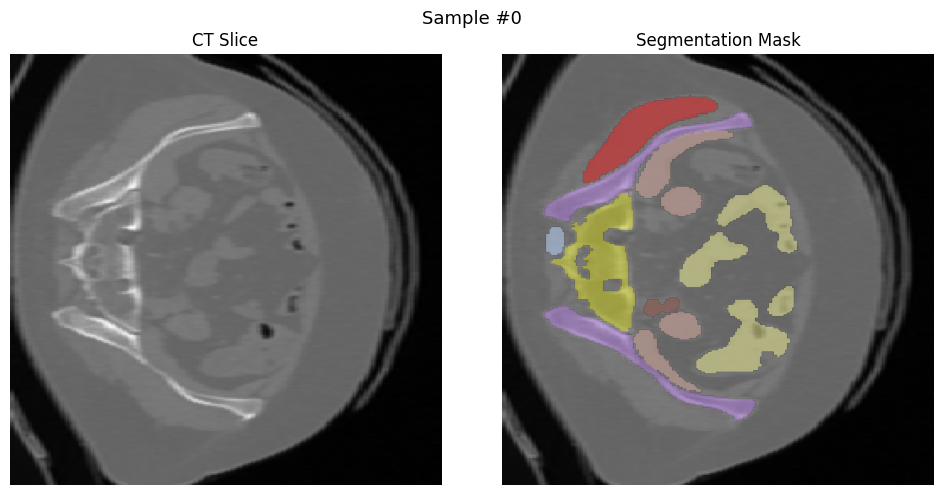

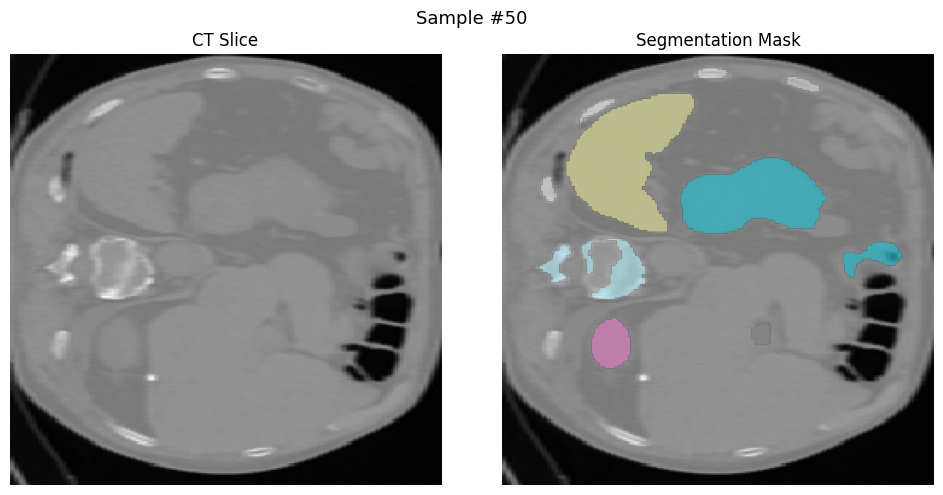

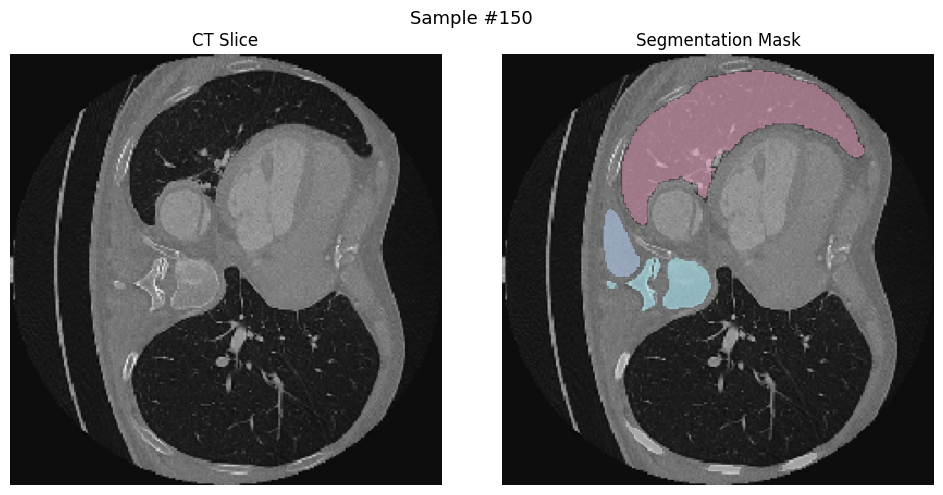

In [7]:
def plot_sample(image, mask_flat, title=""):
    H, W = image.shape
    mask = mask_flat.reshape(H, W)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, cmap="gray"); axes[0].set_title("CT Slice"); axes[0].axis("off")
    overlay = np.ma.masked_where(mask == 0, mask)
    axes[1].imshow(image, cmap="gray")
    axes[1].imshow(overlay, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[1].set_title("Segmentation Mask"); axes[1].axis("off")
    if title: fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

for idx in [0, 50, 150]:
    plot_sample(data_train[idx], labels_train.iloc[idx].values, title=f"Sample #{idx}")

---
## 4. Model Choice <a id='model-choice'></a>

### Why U-Net?

| Criterion | U-Net |
|---|---|
| Spatial precision | Skip connections preserve fine pixel-level detail lost during downsampling |
| Label efficiency | Designed for small medical datasets; works well with <1 000 images |
| Established baseline | Standard first choice in every medical image segmentation benchmark |
| Flexibility | Easy to swap encoder for a pretrained backbone in later iterations |

### Why not the challenge Watershed baseline?
The starter Watershed scores ≈ 0.001 Dice because it assigns region labels with **zero knowledge of organ classes** — the integers it produces are purely topological. A supervised U-Net optimises directly against ground-truth organ masks.

### Architecture
4-level U-Net, channel widths 32 → 64 → 128 → 256 → 512, ~7.7 M parameters. Output: 55-channel logit map (class 0 = background, 1–54 = organs).

---
## 5. Feature Selection & Preprocessing <a id='features'></a>

- **Input**: raw pixel intensities normalised to [0, 1]
- **Resize to 256×256** for tractable training; predictions upsampled back to native resolution before Dice is computed
- **Augmentation (train only)**: random horizontal flip, vertical flip, brightness jitter ±20%
- No hand-crafted features: the convolutional backbone learns task-specific detectors end-to-end

---
## 6. Implementation <a id='implementation'></a>

### Dataset & DataLoader

In [8]:
# ── Reshape flat labels → (N, H, W) ──────────────────────────────────────────
masks_np = labels_train.values.reshape(-1, IMG_H, IMG_W).astype(np.int64)

# ── Train / val split ─────────────────────────────────────────────────────────
val_imgs    = data_train[:VAL_SPLIT]
val_masks   = masks_np[:VAL_SPLIT]
train_imgs  = data_train[VAL_SPLIT:]
train_masks = masks_np[VAL_SPLIT:]

print(f"Train : {train_imgs.shape[0]} images")
print(f"Val   : {val_imgs.shape[0]} images")

Train : 1800 images
Val   : 200 images


In [9]:
class CTSegDataset(Dataset):
    def __init__(self, images, masks, img_size=TRAIN_SIZE, augment=False):
        self.images   = images
        self.masks    = masks
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx].astype(np.float32) / 255.0).unsqueeze(0)  # (1,H,W)
        msk = torch.from_numpy(self.masks[idx]).unsqueeze(0).float()                       # (1,H,W)

        # Resize
        img = F.interpolate(img.unsqueeze(0), size=self.img_size, mode="bilinear",  align_corners=False).squeeze(0)
        msk = F.interpolate(msk.unsqueeze(0), size=self.img_size, mode="nearest").squeeze(0).long()

        # Augmentation
        if self.augment:
            if torch.rand(1) > 0.5:
                img = TF.hflip(img); msk = TF.hflip(msk)
            if torch.rand(1) > 0.5:
                img = TF.vflip(img); msk = TF.vflip(msk)
            factor = 0.8 + 0.4 * torch.rand(1).item()
            img = torch.clamp(img * factor, 0.0, 1.0)

        return img, msk.squeeze(0)   # (1,H,W), (H,W)


train_ds = CTSegDataset(train_imgs, train_masks, augment=True)
val_ds   = CTSegDataset(val_imgs,   val_masks,   augment=False)

# num_workers=2 is fine on Colab Linux; use 0 if you hit any DataLoader errors
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
imgs_b, msks_b = next(iter(train_loader))
print(f"Batch — images: {imgs_b.shape}, masks: {msks_b.shape}")

Batch — images: torch.Size([8, 1, 256, 256]), masks: torch.Size([8, 256, 256])


### U-Net Architecture

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    """4-level U-Net. Input: (B,1,H,W). Output: (B, num_classes, H, W)."""
    def __init__(self, in_channels=1, num_classes=NUM_OUTPUTS, base=32):
        super().__init__()
        self.enc1       = DoubleConv(in_channels, base)
        self.enc2       = Down(base,      base*2)
        self.enc3       = Down(base*2,    base*4)
        self.enc4       = Down(base*4,    base*8)
        self.bottleneck = Down(base*8,    base*16)
        self.dec4       = Up(base*16 + base*8,  base*8)
        self.dec3       = Up(base*8  + base*4,  base*4)
        self.dec2       = Up(base*4  + base*2,  base*2)
        self.dec1       = Up(base*2  + base,    base)
        self.head       = nn.Conv2d(base, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        bn = self.bottleneck(e4)
        return self.head(self.dec1(self.dec2(self.dec3(self.dec4(bn, e4), e3), e2), e1))


model = UNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters : {total_params:,}")

with torch.no_grad():
    dummy = torch.zeros(1, 1, TRAIN_SIZE, TRAIN_SIZE).to(DEVICE)
    print(f"Output shape : {model(dummy).shape}")

Parameters : 7,850,807
Output shape : torch.Size([1, 55, 256, 256])


### Loss, Optimiser, Scheduler

In [11]:
class DiceLoss(nn.Module):
    """Memory-efficient soft Dice — iterates over classes, no full one-hot tensor."""
    def __init__(self, num_classes=NUM_OUTPUTS, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs     = F.softmax(logits, dim=1)   # (B, C, H, W)
        dice_sum  = 0.0
        n_valid   = 0
        for cls in range(1, self.num_classes):  # skip background (0)
            p = probs[:, cls]                   # (B, H, W)
            g = (targets == cls).float()        # (B, H, W)
            inter = (p * g).sum()
            card  = p.sum() + g.sum()
            if card > 0:
                dice_sum += (2.0 * inter + self.smooth) / (card + self.smooth)
                n_valid  += 1
        return 1.0 - dice_sum / max(n_valid, 1)


class CombinedLoss(nn.Module):
    def __init__(self, ce_w=0.5, dice_w=0.5):
        super().__init__()
        self.ce     = nn.CrossEntropyLoss()
        self.dice   = DiceLoss()
        self.ce_w   = ce_w
        self.dice_w = dice_w
    def forward(self, logits, targets):
        return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)


criterion = CombinedLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
print("Loss, optimiser and scheduler ready.")

Loss, optimiser and scheduler ready.


### Training Loop

In [12]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for imgs, masks in tqdm(loader, desc="train" if is_train else "val ", leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, masks)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


best_val_loss = float("inf")
history = {"train": [], "val": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)
    val_loss   = run_epoch(val_loader,   model, criterion, optimizer=None)
    scheduler.step()

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/raidium/best_model.pt")

    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}{'  ✓' if improved else ''}")

print(f"\nBest val loss : {best_val_loss:.4f}")

Epoch   1/30  train=1.8174  val=1.4641  ✓


Epoch   2/30  train=1.1038  val=0.9851  ✓


Epoch   3/30  train=0.7613  val=0.8560  ✓


Epoch   4/30  train=0.6761  val=0.8269  ✓


Epoch   5/30  train=0.6497  val=0.8046  ✓


...

Epoch  26/30  train=0.6010  val=0.7377  ✓


Epoch  27/30  train=0.6003  val=0.7407


Epoch  28/30  train=0.5997  val=0.7396


Epoch  29/30  train=0.5993  val=0.7417


Epoch  30/30  train=0.5988  val=0.7394

Best val loss : 0.7377


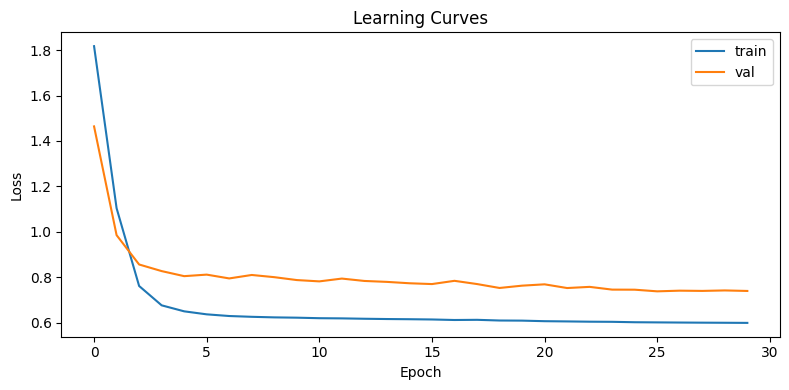

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Learning Curves"); plt.legend()
plt.tight_layout(); plt.show()

---
## 7. Evaluation <a id='evaluation'></a>

In [14]:
# ── Challenge metric (verbatim from starter notebook) ─────────────────────────
def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))

def dice_multiclass(prediction, ground_truth):
    return np.array([
        dice_image(prediction == i, ground_truth == i)
        for i in range(1, NUM_CLASSES + 1)
    ])

def dice_pandas(y_true_df, y_pred_df):
    y_pred_df = y_pred_df.T
    y_true_df = y_true_df.T
    individual_dice = [
        dice_multiclass(y_true_df.values[i].ravel(), y_pred_df.values[i].ravel())
        for i in range(y_true_df.values.shape[0])
    ]
    final = np.stack(individual_dice)
    return float(np.nanmean(np.nanmean(final, axis=0)))

In [15]:
def predict_dataset(images, model, net_size=TRAIN_SIZE, batch_size=8):
    """Run inference → DataFrame (N, H*W) matching challenge label format."""
    model.eval()
    all_preds = []
    for start in tqdm(range(0, len(images), batch_size), desc="Predicting"):
        batch = images[start : start + batch_size]
        t = torch.from_numpy(batch.astype(np.float32) / 255.0).unsqueeze(1)   # (B,1,H,W)
        t = F.interpolate(t, size=net_size, mode="bilinear", align_corners=False).to(DEVICE)
        with torch.no_grad():
            preds = model(t).argmax(dim=1, keepdim=True).float()               # (B,1,h,w)
        preds = F.interpolate(preds, size=(IMG_H, IMG_W), mode="nearest")
        preds = preds.squeeze(1).cpu().numpy().astype(np.int32)                # (B,H,W)
        all_preds.append(preds.reshape(len(batch), -1))
    return pd.DataFrame(np.concatenate(all_preds, axis=0))


# Load best checkpoint
model.load_state_dict(torch.load("/content/raidium/best_model.pt", map_location=DEVICE))

# Predict on validation set
val_preds_df  = predict_dataset(val_imgs, model)
labels_val_df = labels_train.iloc[:VAL_SPLIT]

score = dice_pandas(labels_val_df, val_preds_df)
print(f"\nValidation Dice (challenge metric) : {score:.6f}")
print(f"Challenge watershed baseline       : ~0.0011")

Predicting: 100%|██████████| 25/25 [00:01<00:00, 14.72it/s]



Validation Dice (challenge metric) : 0.000081
Challenge watershed baseline       : ~0.0011


Per-class Dice: 100%|██████████| 200/200 [00:01<00:00, 100.73it/s]


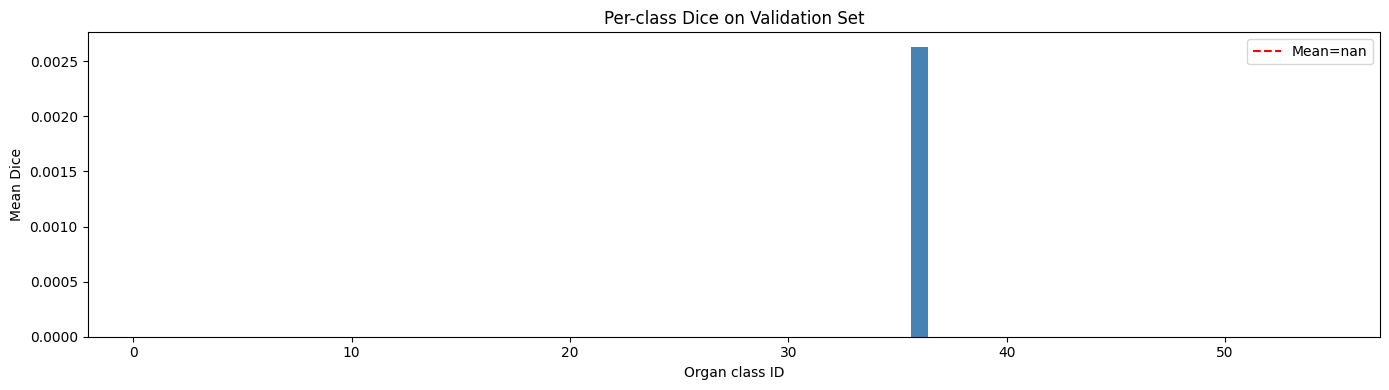

In [16]:
# ── Per-class Dice ─────────────────────────────────────────────────────────────
per_image_dice = [
    dice_multiclass(labels_val_df.values[i].ravel(), val_preds_df.values[i].ravel())
    for i in tqdm(range(len(labels_val_df)), desc="Per-class Dice")
]
cls_dices = np.nanmean(np.stack(per_image_dice), axis=0)

plt.figure(figsize=(14, 4))
plt.bar(np.arange(1, NUM_CLASSES + 1), cls_dices, color="steelblue")
plt.axhline(cls_dices.mean(), color="red", linestyle="--", label=f"Mean={cls_dices.mean():.4f}")
plt.xlabel("Organ class ID"); plt.ylabel("Mean Dice")
plt.title("Per-class Dice on Validation Set"); plt.legend()
plt.tight_layout(); plt.show()

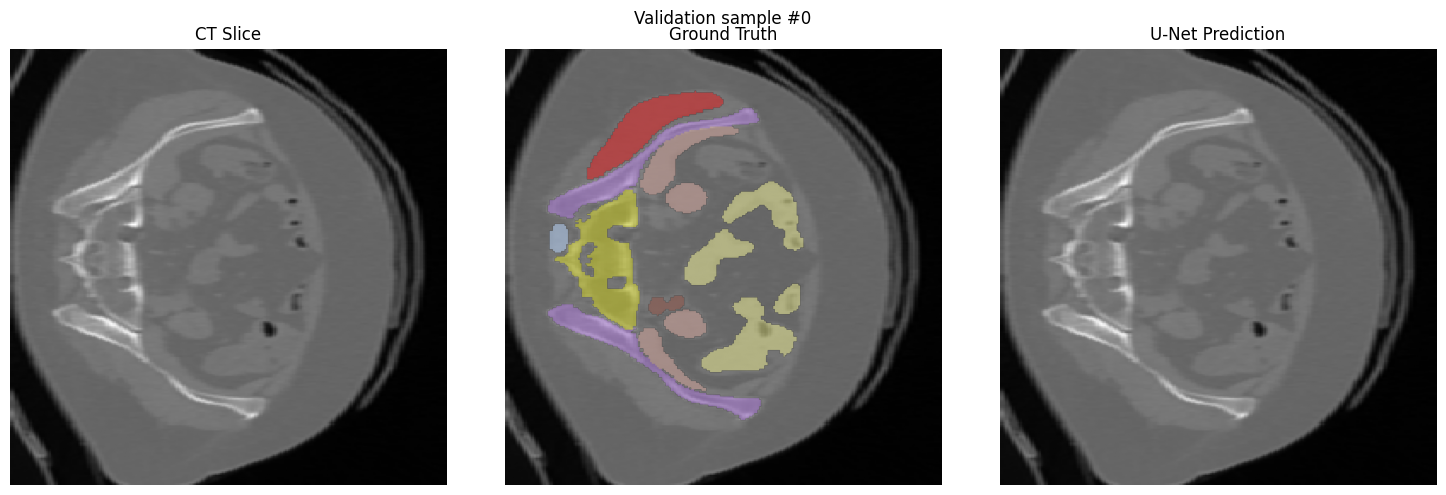

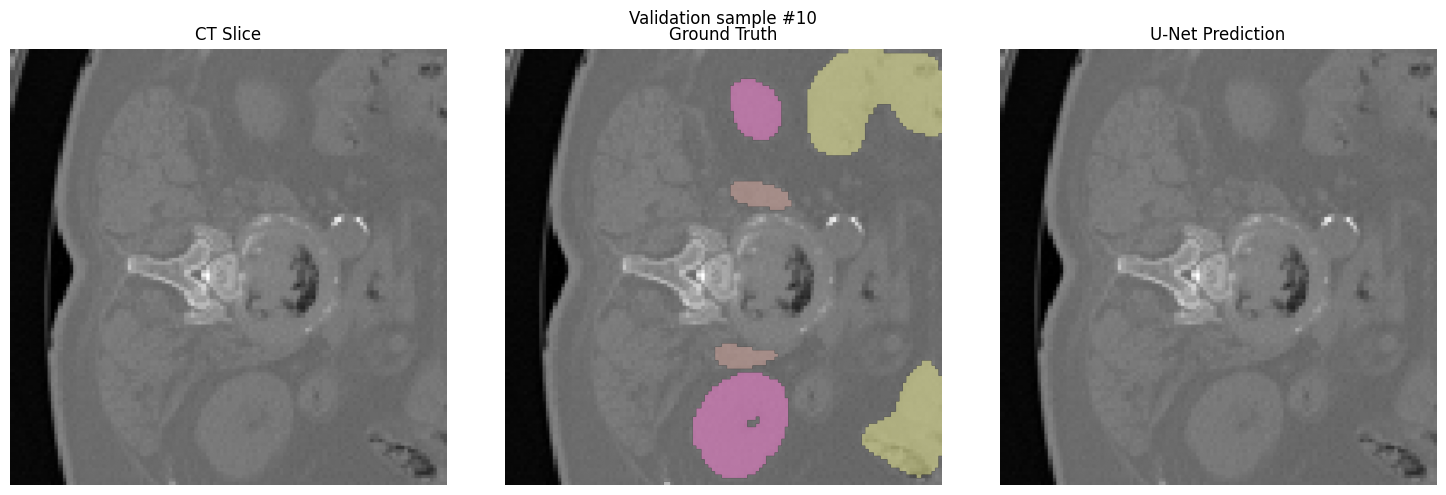

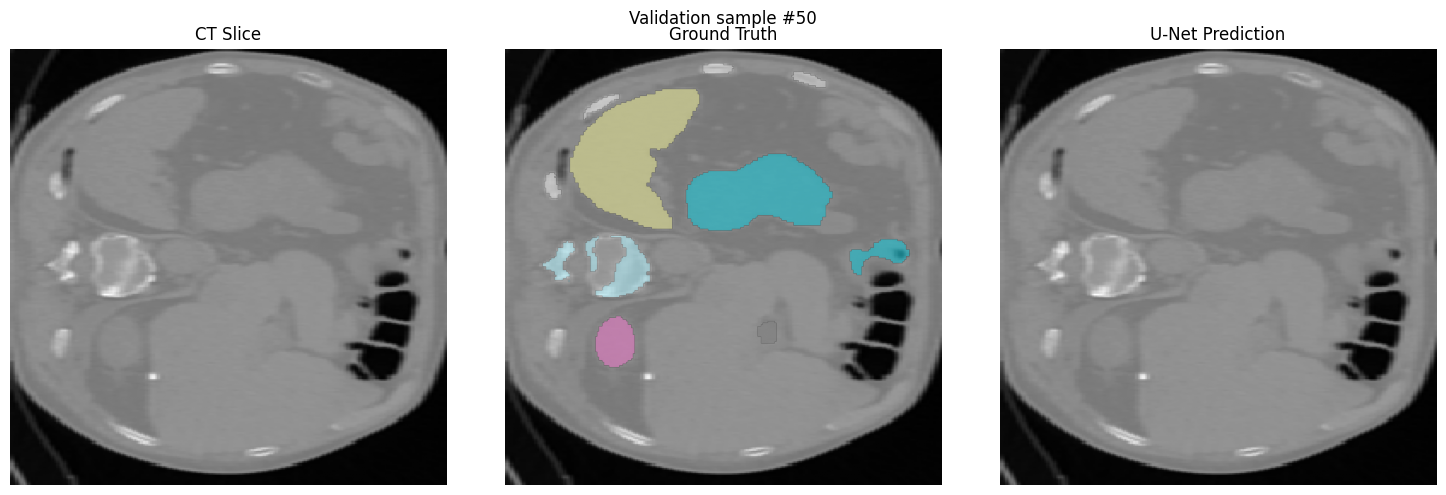

In [17]:
# ── Qualitative inspection ────────────────────────────────────────────────────
val_preds_arr = val_preds_df.values.reshape(VAL_SPLIT, IMG_H, IMG_W)

for idx in [0, 10, 50]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(val_imgs[idx], cmap="gray"); axes[0].set_title("CT Slice"); axes[0].axis("off")

    gt = np.ma.masked_where(val_masks[idx] == 0, val_masks[idx])
    axes[1].imshow(val_imgs[idx], cmap="gray")
    axes[1].imshow(gt, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[1].set_title("Ground Truth"); axes[1].axis("off")

    pr = np.ma.masked_where(val_preds_arr[idx] == 0, val_preds_arr[idx])
    axes[2].imshow(val_imgs[idx], cmap="gray")
    axes[2].imshow(pr, cmap="tab20", alpha=0.6, vmin=1, vmax=NUM_CLASSES)
    axes[2].set_title("U-Net Prediction"); axes[2].axis("off")

    fig.suptitle(f"Validation sample #{idx}"); plt.tight_layout(); plt.show()

---
## 8. Submission <a id='submission'></a>

In [18]:
print("Generating test predictions …")
test_preds_df = predict_dataset(data_test, model)

# Challenge expects the transpose: columns = images, rows = pixels
submission = test_preds_df.T
submission.to_csv("/content/raidium/y_pred.csv")
print(f"Saved → /content/raidium/y_pred.csv  (shape: {submission.shape})")

Generating test predictions …


Predicting: 100%|██████████| 63/63 [00:04<00:00, 14.82it/s]


Saved → /content/raidium/y_pred.csv  (shape: (65536, 500))


In [19]:
# ── Copy submission back to Drive so it survives session reset ────────────────
import shutil
shutil.copy("/content/raidium/y_pred.csv", str(DRIVE_DIR / "y_pred.csv"))
shutil.copy("/content/raidium/best_model.pt", str(DRIVE_DIR / "best_model.pt"))
print("Submission and model checkpoint saved to Google Drive.")

Submission and model checkpoint saved to Google Drive.


---
## Possible Next Steps

1. **Larger input resolution** — train at 512×512; the T4 has 16 GB VRAM which should handle it at batch size 4
2. **Pre-trained encoder** — swap in a ResNet-50 or EfficientNet-B4 backbone
3. **nnU-Net** — `pip install nnunetv2`; auto-configures everything for medical segmentation
4. **Test-Time Augmentation (TTA)** — average predictions over flipped/rotated copies of each image
5. **Class-weighted CE loss** — upweight rare organs to counter class imbalance
6. **Ensemble** — average predictions from multiple checkpoints or architectures